In [ ]:
# 1) Instalar y cargar paquetes (ejecuta solo si no están instalados)
if(!require(bnlearn)) install.packages("bnlearn")
if(!require(gRain)) install.packages("gRain")
if(!require(igraph)) install.packages("igraph")
if(!require(ggplot2)) install.packages("ggplot2")
if(!require(gRbase)) install.packages("gRbase")
#if(!require(Rgraphviz)) install.packages("Rgraphviz")

library(bnlearn)
library(gRain)
library(igraph)
library(ggplot2)
library(gRbase)
#library(Rgraphviz)

## 2) Definición causal (DAG)
Variables (todas binarias/factor):
- TiempoSiembra: ¿Siembra reciente en la zona? (Alta / Baja)
- GenteProblematica: Presencia de actividades humanas de riesgo (Alta / Baja)
- QuemaNoControlada: ¿Se realizan quemas no controladas? (Sí / No)
- TemporadaSeca: ¿Estamos en temporada seca? (Seca / NoSeca)
- RiesgoIncendio: Riesgo final (Alto / Bajo)

Suposiciones causales:
- TiempoSiembra -> QuemaNoControlada (si siembran, hay más probabilidad de quemas)
- GenteProblematica -> QuemaNoControlada
- TemporadaSeca -> RiesgoIncendio (la sequía incrementa la probabilidad de que fuego se propague)
- QuemaNoControlada -> RiesgoIncendio
- (Posible interacción: en temporada seca, el efecto de QuemaNoControlada sobre RiesgoIncendio es mayor)


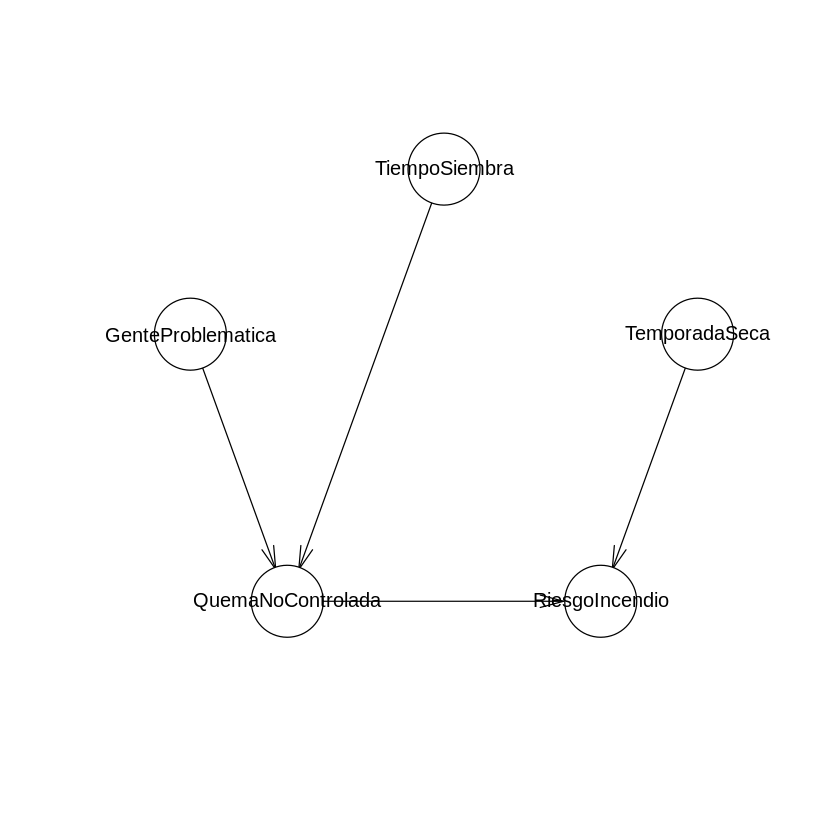

In [ ]:
dag_string <- "[TiempoSiembra][GenteProblematica][TemporadaSeca][QuemaNoControlada|TiempoSiembra:GenteProblematica][RiesgoIncendio|QuemaNoControlada:TemporadaSeca]"
dag <- model2network(dag_string)
plot(dag)  # simple visualización

In [ ]:
set.seed(123)

n <- 5000

# Generamos variables
TiempoSiembra <- sample(c("Alta","Baja"), n, replace=TRUE, prob=c(0.25,0.75))
GenteProblematica <- sample(c("Alta","Baja"), n, replace=TRUE, prob=c(0.15,0.85))

TemporadaSeca <- sample(c("Seca","NoSeca"), n, replace=TRUE, prob=c(0.40, 0.60))

# Probabilidad de QuemaNoControlada condicionada a TiempoSiembra y GenteProblematica.

p_quema <- function(ts, gp){
  if(ts=="Alta" & gp=="Alta") return(0.65)
  if(ts=="Alta" & gp=="Baja") return(0.45)
  if(ts=="Baja" & gp=="Alta") return(0.35)
  return(0.05)
}

QuemaNoControlada <- mapply(function(ts,gp){
  rbinom(1,1,prob = p_quema(ts,gp))
}, TiempoSiembra, GenteProblematica)
QuemaNoControlada <- factor(ifelse(QuemaNoControlada==1,"Si","No"), levels=c("Si","No"))

# RiesgoIncendio depende de QuemaNoControlada y TemporadaSeca.
# Definimos una CPT manual con interacción:

p_riesgo <- function(quema, temp){
  if(quema=="No" & temp=="NoSeca") return(0.02)
  if(quema=="Si" & temp=="NoSeca") return(0.30)
  if(quema=="No" & temp=="Seca") return(0.08)
  if(quema=="Si" & temp=="Seca") return(0.85)
}

RiesgoIncendio <- mapply(function(q,t){
  rbinom(1,1,prob = p_riesgo(q,t))
}, as.character(QuemaNoControlada), TemporadaSeca)
RiesgoIncendio <- factor(ifelse(RiesgoIncendio==1,"Alto","Bajo"), levels=c("Alto","Bajo"))

# Creamos dataframe
data_bn <- data.frame(
  TiempoSiembra = factor(TiempoSiembra, levels=c("Alta","Baja")),
  GenteProblematica = factor(GenteProblematica, levels=c("Alta","Baja")),
  QuemaNoControlada = QuemaNoControlada,
  TemporadaSeca = factor(TemporadaSeca, levels=c("Seca","NoSeca")),
  RiesgoIncendio = RiesgoIncendio
)

# Vista rápida
head(data_bn)
table(data_bn$QuemaNoControlada, data_bn$TemporadaSeca)


,TiempoSiembra,GenteProblematica,QuemaNoControlada,TemporadaSeca,RiesgoIncendio
,<fct>,<fct>,<fct>,<fct>,<fct>
1,Baja,Baja,No,NoSeca,Alto
2,Alta,Alta,Si,NoSeca,Bajo
3,Baja,Baja,No,Seca,Bajo
4,Alta,Baja,Si,NoSeca,Bajo
5,Alta,Baja,No,NoSeca,Bajo
6,Baja,Baja,No,NoSeca,Bajo


    
     Seca NoSeca
  Si  380    568
  No 1575   2477

In [ ]:
# Ajustamos parámetros (fit) usando bn.fit
fit <- bn.fit(dag, data_bn, method="bayes")  # method puede ser "mle" o "bayes"
fit$QuemaNoControlada  # muestra CPT estimada
fit$RiesgoIncendio



  Parameters of node QuemaNoControlada (multinomial distribution)

Conditional probability table:
 
, , TiempoSiembra = Alta

                 GenteProblematica
QuemaNoControlada       Alta       Baja
               Si 0.67638266 0.44593313
               No 0.32361734 0.55406687

, , TiempoSiembra = Baja

                 GenteProblematica
QuemaNoControlada       Alta       Baja
               Si 0.34118439 0.05434867
               No 0.65881561 0.94565133



  Parameters of node RiesgoIncendio (multinomial distribution)

Conditional probability table:
 
, , TemporadaSeca = Seca

              QuemaNoControlada
RiesgoIncendio         Si         No
          Alto 0.86554898 0.08006666
          Bajo 0.13445102 0.91993334

, , TemporadaSeca = NoSeca

              QuemaNoControlada
RiesgoIncendio         Si         No
          Alto 0.31346238 0.01740842
          Bajo 0.68653762 0.98259158


In [ ]:
# Convertir a grain object
grain_obj <- as.grain(fit)
compiled_grain <- compile(grain_obj)
compiled_grain


Independence network: Compiled: TRUE Propagated: FALSE Evidence: FALSE 

## Ejemplos de consultas/escenarios
### Probabilidad marginal de Alto Riesgo


In [ ]:
querygrain(compiled_grain, nodes = c("RiesgoIncendio"), type = "marginal")

$RiesgoIncendio
RiesgoIncendio
    Alto     Bajo 
0.134303 0.865697

In [ ]:
## 7.2 ¿Cuál es la probabilidad de Alto riesgo si estamos en temporada seca?
querygrain(compiled_grain, nodes = c("RiesgoIncendio"), evidence = list(TemporadaSeca="Seca"))

$RiesgoIncendio
RiesgoIncendio
     Alto      Bajo 
0.2289569 0.7710431

In [ ]:
## 7.3 ¿Y si además hay QuemaNoControlada = "Si"?
querygrain(compiled_grain, nodes = c("RiesgoIncendio"), evidence = list(TemporadaSeca="Seca", QuemaNoControlada="Si"))

$RiesgoIncendio
RiesgoIncendio
    Alto     Bajo 
0.865549 0.134451